In [ ]:
import scipy as sc

import jax
import jax.numpy as jp
from jax import config
config.update("jax_enable_x64", True)

from bell import *

from cirq_sic.wh import wh_povm
from cirq_sic.sics import load_sic_fiducial
from cirq_sic.utils import rand_ket

In [2]:
d = 2
n_parties = 2
n_measurements = 2
reference_measurements = np.array([wh_povm(load_sic_fiducial(d)) for i in range(n_parties)])
reference_states = np.array([d*reference_measurements[i] for i in range(n_parties)])
globals().update(construct_joint_reference(reference_measurements, reference_states))

In [3]:
observables, state = example_chsh_saturator()
projectors, labels = construct_projectors(observables, labels=True)
tensor_projectors, tensor_labels = construct_tensor_projectors(projectors, labels=labels)
p = np.einsum("ijk, kj", tensor_projectors, state)
T = construct_T(state, R, projectors, reference_states)
assert np.allclose(T @ phi, p)

bell_functional, classical_bound = chsh_inequality()
float(quantumness_bound(bell_functional, classical_bound, T, phi))

0.17935973380357484

In [4]:
np.linalg.svd(T, compute_uv=False)

array([1.155, 0.471, 0.471, 0.471, 0.471, 0.192, 0.192, 0.192, 0.192,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])

In [5]:
O = observables.reshape(4, 2, 2)
np.array([[(a@b).trace() for b in O] for a in O]).real

array([[ 2.   ,  0.   ,  1.414,  1.414],
       [ 0.   ,  2.   ,  1.414, -1.414],
       [ 1.414,  1.414,  2.   ,  0.   ],
       [ 1.414, -1.414,  0.   ,  2.   ]])

## Optimizing the quantumness bound for CHSH over state and observables. 

This amounts to optimizing over 4 2x2 unitaries and 1 4d state.

In [6]:
@jax.jit
def params_to_stuff(V):
    ket = V[:6].reshape(2,3)
    ket = jp.concatenate([jp.array([1]), ket[0] + 1j*ket[1]])
    ket = ket/jp.linalg.norm(ket)
    U = V[6:].reshape(2,4,2,2)
    U = U[0] + 1j*U[1]
    U = [jp.linalg.qr(u)[0] for u in U]
    return ket, jp.array([[U[0], U[1]], [U[2], U[3]]])

@jax.jit
def obj(V):
    ket, eigvecs = params_to_stuff(V)
    projectors = jp.einsum('...ik,...jk->...kij', eigvecs, eigvecs.conj())
    tensor_projectors = jp.array([reduce(jp.kron, (proj[idx] for proj, idx in zip(projectors, outcome_indices)))\
                                    for outcome_indices in product(*[range(n) for n in [d]*n_parties])])\
                                        .reshape(-1, d**n_parties, d**n_parties)
    PR = jp.einsum("ijk, kj", R, jp.outer(ket, ket.conj())).real
    PER = jp.array([jp.einsum("ijkl, mlk", projectors[i], reference_states[i]) for i in range(n_parties)]).real
    JPER = jp.array([reduce(jp.kron, (per[idx] for per, idx in zip(PER, outcome_indices)))\
                            for outcome_indices in product(*[range(n) for n in [d]*n_parties])])\
                                .reshape(-1, d**(2*n_parties))
    T = jp.kron(JPER, PR).reshape(-1, PR.shape[0]**2)
    T_singular_values = jp.linalg.svd(T, compute_uv=False)
    p = T @ phi
    Delta = bell_functional @ p - classical_bound
    bound = Delta/(jp.max(T_singular_values)*jp.linalg.norm(bell_functional))
    return -bound

result = sc.optimize.minimize(obj, np.random.randn(6 + 4*8),\
                            jac=jax.jit(jax.jacrev(obj)),\
                            tol=1e-16, options={"disp": True, "maxiter": 10000})

ket_opt, eigvecs_opt = params_to_stuff(result.x)
v = np.diag(np.array([-1,1]))
observables_opt = np.array([[eigvecs_opt[i,j] @ v @ eigvecs_opt[i,j].conj().T for j in range(n_measurements)] for i in range(n_parties)])
state_opt = np.outer(ket_opt, ket_opt.conj())

projectors_opt = construct_projectors(observables_opt)
tensor_projectors_opt = construct_tensor_projectors(projectors_opt)

p_opt = np.einsum("ijk, kj", tensor_projectors_opt, state_opt).real
T_opt = construct_T(state_opt, R, projectors_opt, reference_states).real
assert np.allclose(T_opt @ phi, p_opt)
float(quantumness_bound(*chsh_inequality(), T_opt, phi))

/Users/heyredhat/miniforge3/envs/cirq_sic/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -0.179360
         Iterations: 19
         Function evaluations: 64
         Gradient evaluations: 53


0.17935973380357498

In [7]:
p, p_opt

(array([0.427, 0.073, 0.073, 0.427, 0.427, 0.073, 0.073, 0.427, 0.427,
        0.073, 0.073, 0.427, 0.073, 0.427, 0.427, 0.073]),
 array([0.427, 0.073, 0.073, 0.427, 0.427, 0.073, 0.073, 0.427, 0.427,
        0.073, 0.073, 0.427, 0.073, 0.427, 0.427, 0.073]))

In [8]:
bell_functional @ p, bell_functional @ p_opt, 2*np.sqrt(2)

(np.float64(2.828427124746189),
 np.float64(2.8284271247461903),
 np.float64(2.8284271247461903))

In [9]:
np.linalg.svd(T, compute_uv=False), np.linalg.svd(T_opt, compute_uv=False)

(array([1.155, 0.471, 0.471, 0.471, 0.471, 0.192, 0.192, 0.192, 0.192,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([1.155, 0.471, 0.471, 0.471, 0.471, 0.192, 0.192, 0.192, 0.192,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]))

In [10]:
O_opt = observables_opt.reshape(4, 2, 2)
G = np.array([[(a@b).trace() for b in O_opt] for a in O_opt]).real; G

array([[ 2.   ,  0.   , -0.582, -1.135],
       [ 0.   ,  2.   ,  1.007, -1.551],
       [-0.582,  1.007,  2.   ,  0.   ],
       [-1.135, -1.551,  0.   ,  2.   ]])

In [11]:
np.sum(abs(G[:2, 2:]))

np.float64(4.273979423724654)

In [12]:
np.linalg.svd(ket_opt.reshape(2,2))

SVDResult(U=array([[ 0.54 +0.192j,  0.814-0.089j],
       [-0.464+0.675j,  0.086-0.567j]]), S=array([0.707, 0.707]), Vh=array([[ 0.422+0.j   ,  0.3  +0.855j],
       [ 0.906+0.j   , -0.14 -0.398j]]))

In [13]:
import matplotlib.pyplot as plt

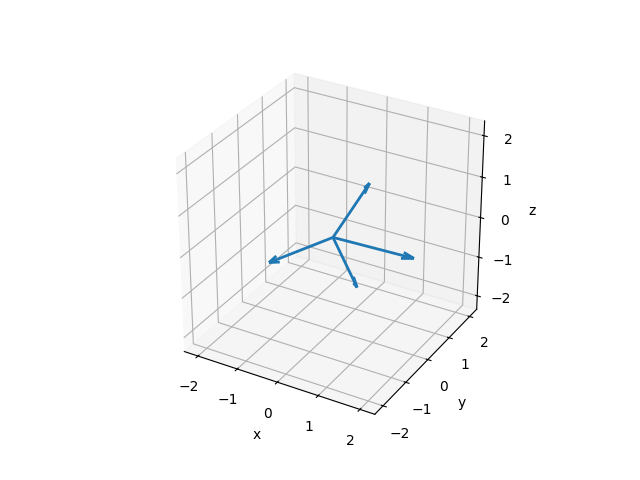

In [14]:
%matplotlib widget

W = [X, Y, Z]
vecs = np.array([[(s@o).trace() for s in W] for o in observables_opt.reshape(4,2,2)]).real

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

origins = np.zeros_like(vecs)
ax.quiver(
    origins[:, 0], origins[:, 1], origins[:, 2],
    vecs[:, 0], vecs[:, 1], vecs[:, 2],
    length=1.0, normalize=False,
    arrow_length_ratio=0.15, linewidth=2, color='tab:blue'
)

# zoom out so every arrow is visible
max_extent = np.abs(vecs).max() * 1.2
for setter in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
    setter(-max_extent, max_extent)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_box_aspect((1, 1, 1))
plt.show()